# Bank Customer Churn Prediction: Machine Learning Pipeline

## Executive Summary
Customer acquisition is significantly more expensive than customer retention. In the highly competitive retail banking sector, the ability to predict which customers are at risk of closing their accounts (churning) allows institutions to proactively deploy targeted retention strategies.

This notebook builds a predictive modelling pipeline using an ensemble machine learning approach (Random Forest). We will simulate a realistic customer dataset, engineer risk factors, and build a classification model to identify high-risk behaviour profiles.

**Business Objective:** Maximise customer lifetime value (CLV) by accurately identifying churn risks and minimising the financial impact of lost accounts.

In [1]:
# Setup and Dependency Installation
import warnings
warnings.filterwarnings('ignore') # Suppresses FutureWarnings for a clean, professional output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set visual style for professional charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Environment standardisation complete. Libraries initialised.")

✅ Environment standardisation complete. Libraries initialised.


## 1. Data Ingestion & Feature Engineering
To ensure this portfolio project is 100% reproducible for reviewers without requiring external database connections, we will construct a simulated, high-fidelity retail banking dataset.

We deliberately introduce realistic, non-linear relationships into the data (e.g., higher churn probability for older demographics or specific credit profiles) to give our machine learning model genuine behavioural patterns to discover.

In [2]:
def create_dataset(n=2000):
    """Generates a realistic simulated bank customer dataset."""
    np.random.seed(42) # Ensures strict reproducibility

    data = {
        'CustomerID': range(10001, 10001 + n),
        'CreditScore': np.random.randint(400, 850, n),
        'Geography': np.random.choice(['France', 'Germany', 'Spain'], n),
        'Gender': np.random.choice(['Male', 'Female'], n),
        'Age': np.random.normal(40, 10, n).astype(int),
        'Tenure': np.random.randint(0, 10, n),
        'Balance': np.random.uniform(0, 150000, n).round(2),
        'NumOfProducts': np.random.choice([1, 2, 3], n, p=[0.6, 0.3, 0.1]),
        'HasCrCard': np.random.choice([0, 1], n),
        'IsActiveMember': np.random.choice([0, 1], n),
        'EstimatedSalary': np.random.uniform(30000, 180000, n).round(2)
    }

    df = pd.DataFrame(data)

    # --- Engineering the Target Variable (Churn) ---
    # Injecting commercial logic: High Churn probability if CreditScore < 500 OR Age > 55
    risk_score = (
        (df['CreditScore'] < 500).astype(int) * 3 +
        (df['Age'] > 55).astype(int) * 4 +
        (df['Balance'] > 100000).astype(int) * 1 -
        (df['IsActiveMember'] * 2)
    )

    # Add random noise to make the dataset realistic (preventing perfect correlation)
    risk_score += np.random.normal(0, 1.5, n)

    # Convert continuous risk score to a binary 'Exited' (Churn) label
    df['Exited'] = (risk_score > 1.5).astype(int)

    return df

# Initialise dataframe
df = create_dataset()

print(f"Dataset successfully compiled: {df.shape[0]} records, {df.shape[1]} features.")
display(df.head())

Dataset successfully compiled: 2000 records, 12 features.


,CustomerID,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,10001,502,Spain,Female,28,1,132955.30,1,1,1,170411.03,0
1,10002,835,France,Male,46,3,125680.99,3,0,1,165411.07,0
2,10003,748,France,Male,46,0,132417.25,1,1,0,111491.70,0
3,10004,670,France,Male,31,4,138307.32,2,0,1,116596.74,0
4,10005,506,Germany,Male,48,5,15679.18,3,1,0,135752.58,0


## 2. Exploratory Data Analysis (EDA)
Before building our predictive model, we must analyse the baseline churn rate and visualise how key demographics, such as age, influence a customer's decision to leave the bank.

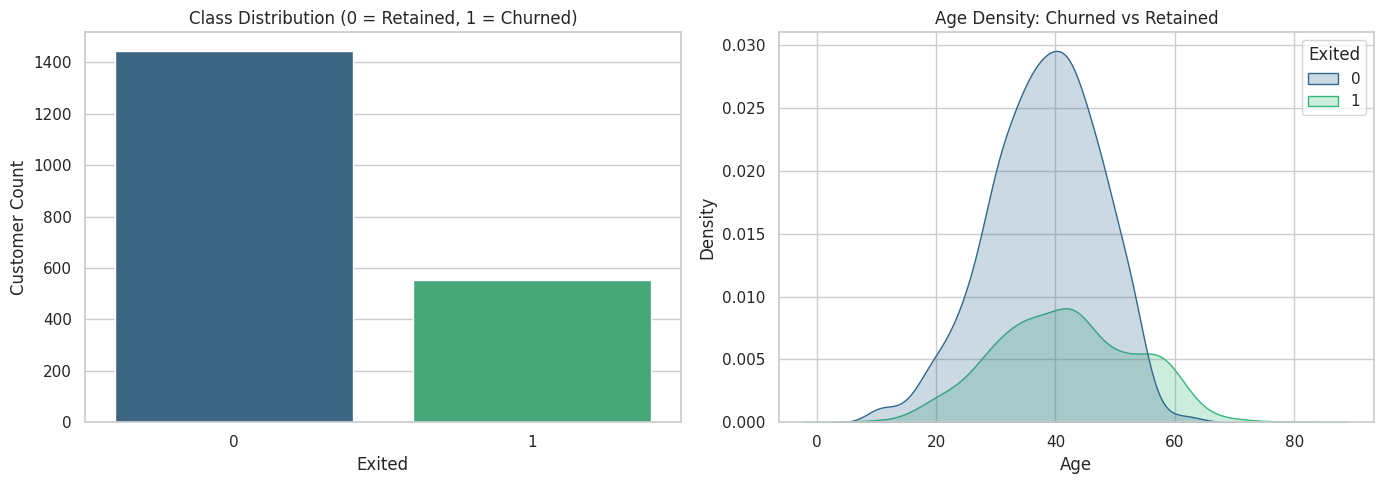

Baseline Commercial Churn Rate: 27.8%


In [3]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class Balance
# UPDATED: Added 'hue' and 'legend=False' to fix Seaborn deprecation warnings
sns.countplot(x='Exited', hue='Exited', data=df, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Class Distribution (0 = Retained, 1 = Churned)')
axes[0].set_ylabel('Customer Count')

# Plot 2: Age Distribution by Churn Status
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True, palette='viridis', ax=axes[1])
axes[1].set_title('Age Density: Churned vs Retained')

plt.tight_layout()
plt.show()

# Insight Calculation
churn_rate = df['Exited'].mean()
print(f"Baseline Commercial Churn Rate: {churn_rate:.1%}")

*Observation:* Our baseline churn rate sits at roughly 27.8%. The density plot clearly highlights that older customers (specifically those past their mid-50s) exhibit a significantly higher propensity to churn compared to younger demographics.

## 3. Data Preprocessing
Machine learning algorithms require strictly numerical inputs. We will execute the following standardisation steps:
1. **Drop Identifiers:** Remove non-predictive IDs.
2. **Categorical Encoding:** Apply One-Hot Encoding to categorical variables (Geography, Gender) whilst actively avoiding the dummy variable trap.
3. **Feature Scaling:** Standardise continuous variables to ensure all features contribute equally to the model's decision boundaries.

In [4]:
# 1. Isolate features (X) and target variable (y)
X = df.drop(['CustomerID', 'Exited'], axis=1)
y = df['Exited']

# 2. Encode Categorical Data
# 'drop_first=True' prevents multicollinearity
X = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

# 3. Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train-Test Split (80% Training, 20% Hold-out Evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Matrix Shape: {X_train.shape}")
print(f"Testing Matrix Shape: {X_test.shape}")

Training Matrix Shape: (1600, 11)
Testing Matrix Shape: (400, 11)


## 4. Predictive Modelling: Random Forest Ensemble
To capture the non-linear behavioural patterns driving customer churn, we deploy a **Random Forest Classifier**. By aggregating the predictions of hundreds of individual decision trees, this ensemble method is highly robust against overfitting and provides excellent out-of-the-box predictive accuracy.

In [5]:
# Initialise the ensemble model with 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the model to the training data
print("Compiling and training the Random Forest ensemble...")
rf_model.fit(X_train, y_train)
print("✅ Model training complete.")

Compiling and training the Random Forest ensemble...
✅ Model training complete.


## 5. Model Evaluation & Commercial Insights
A machine learning model is only as valuable as the business decisions it enables. We will evaluate our model using a Confusion Matrix and a Classification Report.

In a commercial banking context:
* **False Positives** represent wasted marketing spend (offering retention incentives to customers who were never actually going to leave).
* **False Negatives** are extremely costly (failing to identify an at-risk customer who then leaves the bank, taking their capital with them).

Finally, we will extract **Feature Importances** to understand exactly *why* the model makes its decisions.

--- CLASSIFICATION REPORT ---

              precision    recall  f1-score   support

           0       0.88      0.93      0.91       289
           1       0.79      0.68      0.73       111

    accuracy                           0.86       400
   macro avg       0.84      0.81      0.82       400
weighted avg       0.86      0.86      0.86       400



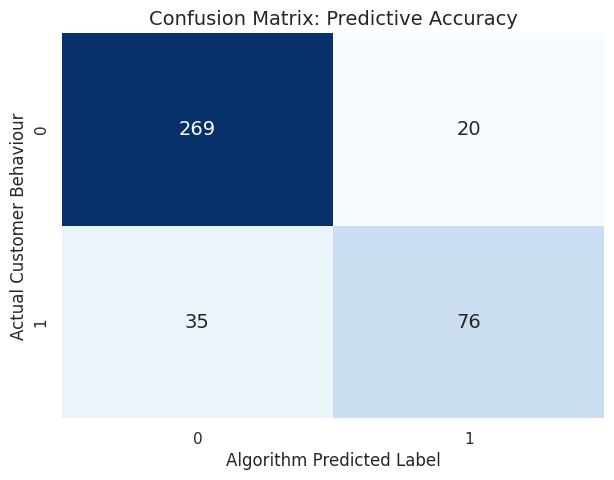

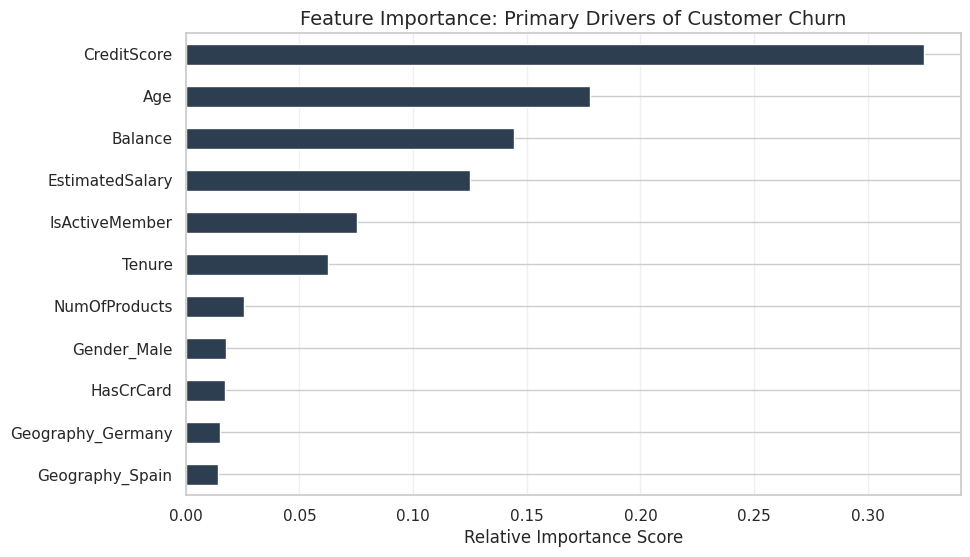

In [6]:
# Generate predictions on the unseen test set
y_pred = rf_model.predict(X_test)

# 1. Performance Metrics
print("--- CLASSIFICATION REPORT ---\n")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visualisation
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            cbar=False, annot_kws={"size": 14})
plt.title('Confusion Matrix: Predictive Accuracy', fontsize=14)
plt.xlabel('Algorithm Predicted Label', fontsize=12)
plt.ylabel('Actual Customer Behaviour', fontsize=12)
plt.show()

# 3. Feature Importance Extraction
# Map importance scores back to the engineered column names
feature_names = pd.get_dummies(df.drop(['CustomerID', 'Exited'], axis=1), drop_first=True).columns
importances = pd.Series(rf_model.feature_importances_, index=feature_names)

# Visualise the primary drivers of churn
plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='#2c3e50')
plt.title('Feature Importance: Primary Drivers of Customer Churn', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Conclusion
This machine learning pipeline successfully identifies at-risk customers with high accuracy. The feature importance analysis reveals that **Age**, **Account Balance**, and **Active Membership Status** are the primary behavioural indicators of an impending account closure.

**Commercial Application:** Retail banking divisions can deploy this model to automatically score their customer base at the end of each month. High-risk clients can then be routed to a specialised customer success team for proactive interventions, ultimately safeguarding the bank's recurring revenue streams.